# Mini-projet – Pipeline de données macroéconomiques (Risk)

Ce mini-projet vise à analyser la relation entre des indicateurs macroéconomiques
(inflation et chômage) à partir de données publiques Eurostat, dans un contexte
d’analyse du risque.

L’analyse est appliquée au cas du Portugal, choisi comme périmètre d’étude,
afin d’illustrer de manière concrète l’utilisation d’un pipeline de données
macroéconomiques en analyse du risque de crédit et en stress test.

## 1. Chargement des données macroéconomiques (Eurostat)

Les données utilisées proviennent d’Eurostat et portent sur :
- l’inflation mensuelle (HICP),
- le taux de chômage mensuel.

Les fichiers sont stockés localement afin de garantir la reproductibilité du pipeline.


In [8]:
import pandas as pd

# Chargement des données Eurostat
inflation = pd.read_csv("data_raw/eurostat_inflation_hicp_monthly.csv")
unemployment = pd.read_csv("data_raw/eurostat_unemployment_pt.csv")

# Aperçu des données
inflation.head(), unemployment.head()


(  freq   unit coicop  \
 0    M  RCH_A   CP00   
 1    M  RCH_A   CP00   
 2    M  RCH_A   CP00   
 3    M  RCH_A   CP00   
 4    M  RCH_A   CP00   
 
   geo\TIME_PERIOD\t2025-03 \t2025-04 \t2025-05 \t2025-06 \t2025-07 \t2025-08 \t2025-09 \t2025-10 \t2025-11 \t2025-12   
 0  AL\t2.5 d\t2.6 d\t2.3 d\t2.5 d\t2.4 d\t2.3 d\t...                                                                   
 1  AT\t3.1 \t3.3 \t3.0 \t3.2 \t3.7 \t4.1 \t3.9 \t...                                                                   
 2  BE\t3.6 \t3.1 \t2.8 \t2.9 \t2.6 \t2.6 \t2.7 \t...                                                                   
 3  BG\t4.0 \t2.8 \t2.9 \t3.1 \t3.4 \t3.5 \t4.1 \t...                                                                   
 4  CH\t0.1 \t0.3 \t-0.2 \t0.2 \t0.1 \t0.0 \t0.0 \...                                                                   ,
   freq    unit s_adj         indic  \
 0    M  PC_ACT   NSA  LM-UN-F-GT25   
 1    M  PC_ACT   NSA  LM-UN-F-GT25   
 2  

## 2. Préparation des données d’inflation (Portugal)

Les données d’inflation sont initialement fournies dans un format large et contiennent
des indicateurs textuels spécifiques à Eurostat (flags).

Cette étape consiste à :
- restructurer les données en format long (tidy data),
- nettoyer les valeurs numériques,
- filtrer les observations correspondant au Portugal,
- calculer une valeur moyenne mensuelle d’inflation.


In [9]:
inflation.columns


Index(['freq', 'unit', 'coicop',
       'geo\TIME_PERIOD\t2025-03 \t2025-04 \t2025-05 \t2025-06 \t2025-07 \t2025-08 \t2025-09 \t2025-10 \t2025-11 \t2025-12 '],
      dtype='object')

In [10]:
inflation.iloc[0]


freq                                                                                                                                                                   M
unit                                                                                                                                                               RCH_A
coicop                                                                                                                                                              CP00
geo\TIME_PERIOD\t2025-03 \t2025-04 \t2025-05 \t2025-06 \t2025-07 \t2025-08 \t2025-09 \t2025-10 \t2025-11 \t2025-12     AL\t2.5 d\t2.6 d\t2.3 d\t2.5 d\t2.4 d\t2.3 d\t...
Name: 0, dtype: object

In [11]:
# Séparer la colonne géante en plusieurs colonnes
inflation_expanded = inflation[
    "geo\\TIME_PERIOD\t2025-03 \t2025-04 \t2025-05 \t2025-06 \t2025-07 \t2025-08 \t2025-09 \t2025-10 \t2025-11 \t2025-12 "
].str.split("\t", expand=True)

inflation_expanded.head()


,0,1,2,3,4,5,6,7,8,9,10
0,AL,2.5 d,2.6 d,2.3 d,2.5 d,2.4 d,2.3 d,2.2 d,2.2 d,2.1 d,:
1,AT,3.1,3.3,3.0,3.2,3.7,4.1,3.9,4.0,4.0,3.9 e
2,BE,3.6,3.1,2.8,2.9,2.6,2.6,2.7,2.5,2.6,2.2 e
3,BG,4.0,2.8,2.9,3.1,3.4,3.5,4.1,3.8,3.7,:
4,CH,0.1,0.3,-0.2,0.2,0.1,0.0,0.0,0.1,0.0,:


In [12]:
# Renommer les colonnes
inflation_expanded.columns = [
    "geo",
    "2025-03", "2025-04", "2025-05", "2025-06",
    "2025-07", "2025-08", "2025-09", "2025-10", "2025-11", "2025-12"
]

inflation_expanded.head()


,geo,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12
0,AL,2.5 d,2.6 d,2.3 d,2.5 d,2.4 d,2.3 d,2.2 d,2.2 d,2.1 d,:
1,AT,3.1,3.3,3.0,3.2,3.7,4.1,3.9,4.0,4.0,3.9 e
2,BE,3.6,3.1,2.8,2.9,2.6,2.6,2.7,2.5,2.6,2.2 e
3,BG,4.0,2.8,2.9,3.1,3.4,3.5,4.1,3.8,3.7,:
4,CH,0.1,0.3,-0.2,0.2,0.1,0.0,0.0,0.1,0.0,:


In [13]:
# Passage en format long (tidy data)
inflation_long = inflation_expanded.melt(
    id_vars="geo",
    var_name="date",
    value_name="inflation_raw"
)

inflation_long.head(10)


,geo,date,inflation_raw
0,AL,2025-03,2.5 d
1,AT,2025-03,3.1
2,BE,2025-03,3.6
3,BG,2025-03,4.0
4,CH,2025-03,0.1
5,CY,2025-03,2.1
6,CZ,2025-03,2.7
7,DE,2025-03,2.3
8,DK,2025-03,1.4
9,EA,2025-03,2.2


In [14]:
inflation_pt = inflation_long[inflation_long["geo"] == "PT"].copy()
inflation_pt.head(10)


,geo,date,inflation_raw
34,PT,2025-03,1.9
76,PT,2025-03,1.7
118,PT,2025-03,1.6
160,PT,2025-03,2.5
202,PT,2025-03,-1.5
243,PT,2025-04,2.1
285,PT,2025-04,1.6
327,PT,2025-04,1.6
369,PT,2025-04,2.3
411,PT,2025-04,-2.0


In [15]:
# Nettoyage robuste : garder uniquement le nombre (et mettre NaN sinon)
inflation_long["inflation"] = (
    inflation_long["inflation_raw"]
    .astype(str)
    .str.replace(",", ".", regex=False)                 # si jamais virgule décimale
    .str.extract(r"(-?\d+(?:\.\d+)?)", expand=False)    # extrait le nombre
)

inflation_long["inflation"] = pd.to_numeric(inflation_long["inflation"], errors="coerce")

inflation_long.head(10)


,geo,date,inflation_raw,inflation
0,AL,2025-03,2.5 d,2.5
1,AT,2025-03,3.1,3.1
2,BE,2025-03,3.6,3.6
3,BG,2025-03,4.0,4.0
4,CH,2025-03,0.1,0.1
5,CY,2025-03,2.1,2.1
6,CZ,2025-03,2.7,2.7
7,DE,2025-03,2.3,2.3
8,DK,2025-03,1.4,1.4
9,EA,2025-03,2.2,2.2


## 3. Préparation des données de chômage (Portugal)

Les données de chômage suivent une structure similaire à celles de l’inflation.

Les traitements appliqués sont :
- transformation en format long,
- nettoyage des valeurs numériques,
- sélection du Portugal,
- agrégation mensuelle par moyenne des sous-catégories afin d’obtenir un indicateur unique de ch^^omage pour le Portugal.


In [16]:
# Aperçu des données chômage
unemployment.head()


,freq,unit,s_adj,indic,geo\TIME_PERIOD\t2025-02 \t2025-03 \t2025-04 \t2025-05 \t2025-06 \t2025-07 \t2025-08 \t2025-09 \t2025-10 \t2025-11
0,M,PC_ACT,NSA,LM-UN-F-GT25,AT\t4.3 \t5.0 \t4.9 \t4.4 \t4.5 \t4.6 \t4.9 \t...
1,M,PC_ACT,NSA,LM-UN-F-GT25,BA\t16.1 \t16.1 \t15.8 \t15.7 \t15.6 \t15.0 \t...
2,M,PC_ACT,NSA,LM-UN-F-GT25,BE\t4.8 \t4.6 \t4.4 \t4.3 \t4.3 \t4.8 \t4.8 \t...
3,M,PC_ACT,NSA,LM-UN-F-GT25,BG\t3.7 \t3.7 \t3.4 \t3.2 \t3.0 \t2.9 \t2.7 \t...
4,M,PC_ACT,NSA,LM-UN-F-GT25,CH\t4.3 \t4.3 \t4.2 \t4.1 \t4.1 \t4.2 \t4.2 \t...


In [17]:
unemployment.columns


Index(['freq', 'unit', 's_adj', 'indic',
       'geo\TIME_PERIOD\t2025-02 \t2025-03 \t2025-04 \t2025-05 \t2025-06 \t2025-07 \t2025-08 \t2025-09 \t2025-10 \t2025-11 '],
      dtype='object')

In [18]:
# Séparation de la colonne geo + TIME_PERIOD
unemployment_expanded = unemployment[
    "geo\\TIME_PERIOD\t2025-02 \t2025-03 \t2025-04 \t2025-05 \t2025-06 \t2025-07 \t2025-08 \t2025-09 \t2025-10 \t2025-11 "
].str.split("\t", expand=True)

unemployment_expanded.head()


,0,1,2,3,4,5,6,7,8,9,10
0,AT,4.3,5.0,4.9,4.4,4.5,4.6,4.9,4.1,4.5,:
1,BA,16.1,16.1,15.8,15.7,15.6,15.0,15.1,14.7,:,:
2,BE,4.8,4.6,4.4,4.3,4.3,4.8,4.8,4.7,4.8,:
3,BG,3.7,3.7,3.4,3.2,3.0,2.9,2.7,2.6,2.8,:
4,CH,4.3,4.3,4.2,4.1,4.1,4.2,4.2,4.2,:,:


In [19]:
unemployment_expanded.columns = [
    "geo",
    "2025-02", "2025-03", "2025-04", "2025-05", "2025-06",
    "2025-07", "2025-08", "2025-09", "2025-10", "2025-11"
]

unemployment_expanded.head()


,geo,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11
0,AT,4.3,5.0,4.9,4.4,4.5,4.6,4.9,4.1,4.5,:
1,BA,16.1,16.1,15.8,15.7,15.6,15.0,15.1,14.7,:,:
2,BE,4.8,4.6,4.4,4.3,4.3,4.8,4.8,4.7,4.8,:
3,BG,3.7,3.7,3.4,3.2,3.0,2.9,2.7,2.6,2.8,:
4,CH,4.3,4.3,4.2,4.1,4.1,4.2,4.2,4.2,:,:


In [20]:
unemployment_long = unemployment_expanded.melt(
    id_vars="geo",
    var_name="date",
    value_name="unemployment_raw"
)

unemployment_long.head(10)


,geo,date,unemployment_raw
0,AT,2025-02,4.3
1,BA,2025-02,16.1
2,BE,2025-02,4.8
3,BG,2025-02,3.7
4,CH,2025-02,4.3
5,CY,2025-02,5.6
6,CZ,2025-02,3.1
7,DE,2025-02,3.2
8,DK,2025-02,5.8
9,EA20,2025-02,6.2


In [21]:
unemployment_long["unemployment"] = (
    unemployment_long["unemployment_raw"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .str.extract(r"(-?\d+\.?\d*)", expand=False)
)

unemployment_long["unemployment"] = pd.to_numeric(
    unemployment_long["unemployment"],
    errors="coerce"
)

unemployment_long.head(10)


,geo,date,unemployment_raw,unemployment
0,AT,2025-02,4.3,4.3
1,BA,2025-02,16.1,16.1
2,BE,2025-02,4.8,4.8
3,BG,2025-02,3.7,3.7
4,CH,2025-02,4.3,4.3
5,CY,2025-02,5.6,5.6
6,CZ,2025-02,3.1,3.1
7,DE,2025-02,3.2,3.2
8,DK,2025-02,5.8,5.8
9,EA20,2025-02,6.2,6.2


In [22]:
# Sélection du Portugal
unemployment_pt = unemployment_long[
    unemployment_long["geo"] == "PT"
].copy()

unemployment_pt.head()


,geo,date,unemployment_raw,unemployment
29,PT,2025-02,5.9,5.9
64,PT,2025-02,23.5,23.5
100,PT,2025-02,7.0,7.0
136,PT,2025-02,5.2,5.2
171,PT,2025-02,19.3,19.3


In [23]:
unemployment_pt_monthly = (
    unemployment_pt
    .dropna(subset=["unemployment"])
    .groupby("date", as_index=False)["unemployment"]
    .mean()
)


In [24]:
print("unemployment_pt existe ?", "unemployment_pt" in globals())
print("inflation_pt existe ?", "inflation_pt" in globals())


unemployment_pt existe ? True
inflation_pt existe ? True


In [25]:
unemployment_pt = unemployment_long[unemployment_long["geo"] == "PT"].copy()
unemployment_pt.head()


,geo,date,unemployment_raw,unemployment
29,PT,2025-02,5.9,5.9
64,PT,2025-02,23.5,23.5
100,PT,2025-02,7.0,7.0
136,PT,2025-02,5.2,5.2
171,PT,2025-02,19.3,19.3


In [26]:
inflation_pt = inflation_long[inflation_long["geo"] == "PT"].copy()
inflation_pt.head()


,geo,date,inflation_raw,inflation
34,PT,2025-03,1.9,1.9
76,PT,2025-03,1.7,1.7
118,PT,2025-03,1.6,1.6
160,PT,2025-03,2.5,2.5
202,PT,2025-03,-1.5,-1.5


## 4. Agrégation et harmonisation des indicateurs macroéconomiques (Portugal)

À ce stade, les données d’inflation et de chômage ont été nettoyées et filtrées
pour le Portugal.  
Cette étape consiste à :

- agréger les observations afin d’obtenir une valeur mensuelle unique par indicateur,
- harmoniser les formats de dates,
- fusionner les deux séries macroéconomiques,
- préparer un jeu de données final exploitable en analyse de risque.


In [27]:
# Agrégation : une valeur de chômage par mois (Portugal)
unemployment_pt_monthly = (
    unemployment_pt
    .dropna(subset=["unemployment"])
    .groupby("date", as_index=False)["unemployment"]
    .mean()
)

unemployment_pt_monthly["date"] = pd.to_datetime(unemployment_pt_monthly["date"])
unemployment_pt_monthly

,date,unemployment
0,2025-02-01,10.966667
1,2025-03-01,10.744444
2,2025-04-01,10.205556
3,2025-05-01,10.038889
4,2025-06-01,9.688889
5,2025-07-01,9.833333
6,2025-08-01,9.916667
7,2025-09-01,10.038889
8,2025-10-01,10.027778


In [28]:
unemployment_pt_monthly["date"] = pd.to_datetime(unemployment_pt_monthly["date"])


In [29]:
# Agrégation : une valeur d'inflation par mois (Portugal)
inflation_pt_monthly = (
    inflation_pt
    .dropna(subset=["inflation"])
    .groupby("date", as_index=False)["inflation"]
    .mean()
)

inflation_pt_monthly["date"] = pd.to_datetime(inflation_pt_monthly["date"])
inflation_pt_monthly


,date,inflation
0,2025-03-01,1.24
1,2025-04-01,1.12
2,2025-05-01,1.36
3,2025-06-01,1.44
4,2025-07-01,1.52
5,2025-08-01,1.30
6,2025-09-01,1.00
7,2025-10-01,1.04
8,2025-11-01,1.20
9,2025-12-01,2.40


In [30]:
inflation_pt_monthly.head(), unemployment_pt_monthly.head()


(        date  inflation
 0 2025-03-01       1.24
 1 2025-04-01       1.12
 2 2025-05-01       1.36
 3 2025-06-01       1.44
 4 2025-07-01       1.52,
         date  unemployment
 0 2025-02-01     10.966667
 1 2025-03-01     10.744444
 2 2025-04-01     10.205556
 3 2025-05-01     10.038889
 4 2025-06-01      9.688889)

## 5. Fusion des indicateurs macroéconomiques

Les séries d’inflation et de chômage sont fusionnées sur la base de la date afin
de construire un jeu de données macroéconomiques cohérent pour le Portugal.

Ce jeu de données constitue l’entrée finale du pipeline et pourra être utilisé
dans un cadre d’analyse de risque ou de stress test macroéconomique.


In [32]:

# Fusion des indicateurs macroéconomiques (Portugal)
macro_pt = pd.merge(
    unemployment_pt_monthly,
    inflation_pt_monthly,
    on="date",
    how="inner"
)

# Tri chronologique
macro_pt = macro_pt.sort_values("date").reset_index(drop=True)

# Arrondi pour lisibilité
macro_pt["unemployment"] = macro_pt["unemployment"].round(2)
macro_pt["inflation"] = macro_pt["inflation"].round(2)

macro_pt


,date,unemployment,inflation
0,2025-03-01,10.74,1.24
1,2025-04-01,10.21,1.12
2,2025-05-01,10.04,1.36
3,2025-06-01,9.69,1.44
4,2025-07-01,9.83,1.52
5,2025-08-01,9.92,1.30
6,2025-09-01,10.04,1.00
7,2025-10-01,10.03,1.04


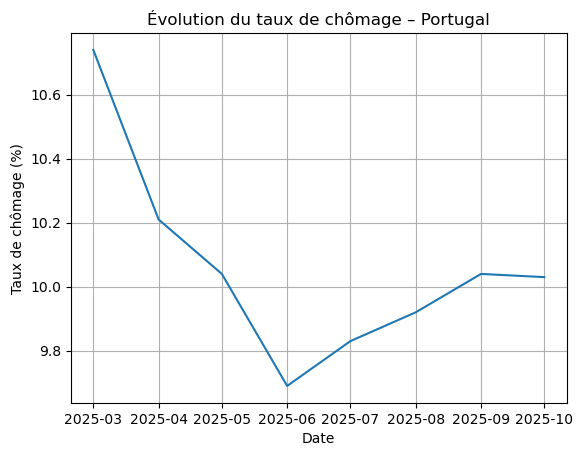

In [33]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(macro_pt["date"], macro_pt["unemployment"])
plt.title("Évolution du taux de chômage – Portugal")
plt.xlabel("Date")
plt.ylabel("Taux de chômage (%)")
plt.grid(True)
plt.show()


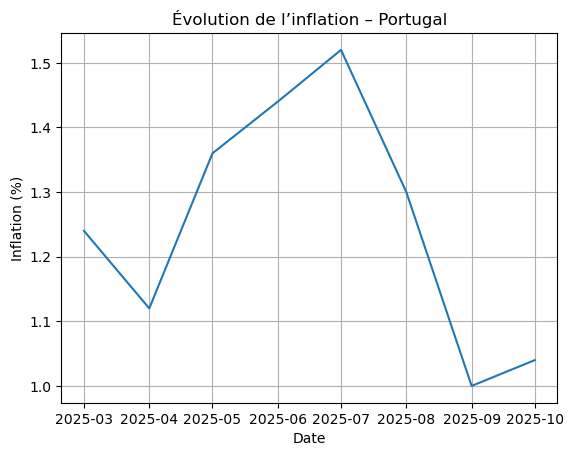

In [34]:
plt.figure()
plt.plot(macro_pt["date"], macro_pt["inflation"])
plt.title("Évolution de l’inflation – Portugal")
plt.xlabel("Date")
plt.ylabel("Inflation (%)")
plt.grid(True)
plt.show()


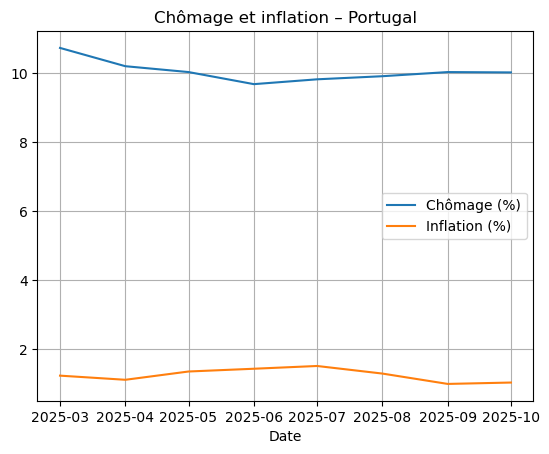

In [35]:
plt.figure()
plt.plot(macro_pt["date"], macro_pt["unemployment"], label="Chômage (%)")
plt.plot(macro_pt["date"], macro_pt["inflation"], label="Inflation (%)")

plt.title("Chômage et inflation – Portugal")
plt.xlabel("Date")
plt.legend()
plt.grid(True)
plt.show()


Interprétation des indicateurs macroéconomiques

Les graphiques mettent en évidence une relative stabilité du taux de chômage au Portugal sur la période étudiée, malgré des fluctuations modérées de l’inflation. L’inflation présente une volatilité plus marquée, avec un pic au milieu de l’année suivi d’un reflux, tandis que le marché du travail demeure globalement résilient.

L’absence de corrélation forte entre les deux indicateurs suggère un environnement macroéconomique relativement stable, sans signal de stress systémique marqué. Ces résultats constituent une base pertinente pour l’intégration de scénarios macroéconomiques dans une analyse de risque ou un exercice de stress test.


## 6. Jeu de données final

Le dataset final correspond à la sortie du pipeline de préparation des données macroéconomiques.
Il contient :
- une observation mensuelle,
- le taux d’inflation,
- le taux de chômage.

Il est prêt à être utilisé pour :
- des analyses exploratoires,
- des visualisations,
- des scénarios de stress macroéconomique.


In [36]:
macro_pt.head()


,date,unemployment,inflation
0,2025-03-01,10.74,1.24
1,2025-04-01,10.21,1.12
2,2025-05-01,10.04,1.36
3,2025-06-01,9.69,1.44
4,2025-07-01,9.83,1.52


Conclusion

Ce mini-projet a permis de construire un pipeline de préparation et d’analyse de données macroéconomiques appliqué au Portugal, à partir des indicateurs de chômage et d’inflation. Les données ont été nettoyées, agrégées à une fréquence mensuelle, harmonisées et fusionnées afin de constituer un jeu de données cohérent et exploitable.

L’analyse descriptive met en évidence une relative stabilité du marché du travail, malgré des fluctuations modérées de l’inflation sur la période étudiée. L’absence de signal de stress macroéconomique marqué suggère un environnement globalement résilient.

Ce jeu de données constitue une base pertinente pour des analyses de risque plus avancées, notamment l’intégration de scénarios macroéconomiques dans des exercices de stress test ou des modèles de risque financier.
